# Car Price Prediction using Machine Learning 🚗


## 📥 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

## 📂 Reading Dataset And Get Info 

In [2]:
df = pd.read_csv('/kaggle/input/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv')

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 📊 1. Data Exploration and Handling Missing Values


In [3]:
print(f"Dataset Shape: {df.shape}")

print("Missing Values:\n", df.isnull().sum())

Dataset Shape: (4340, 8)
Missing Values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


## 🔍 2. Price Distribution


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


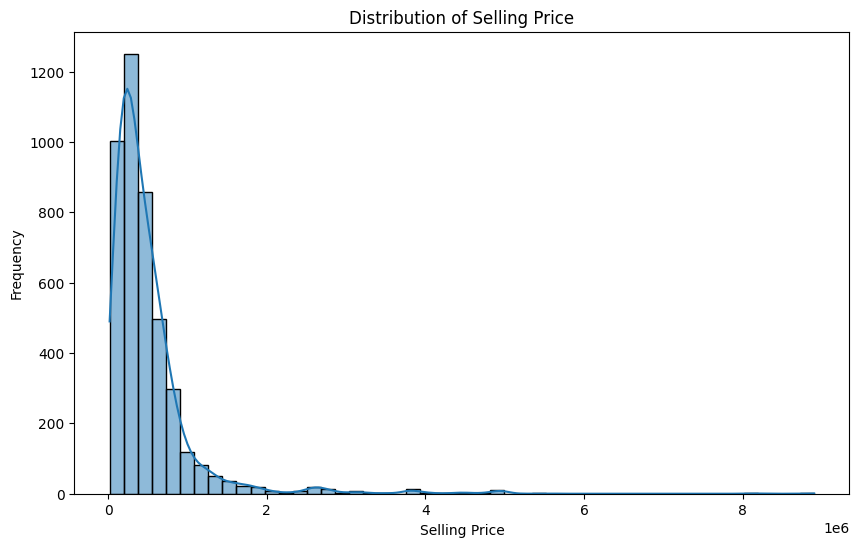

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], kde=True, bins=50)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

## 🔢 3. Log Transformation and Removing Outliers


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


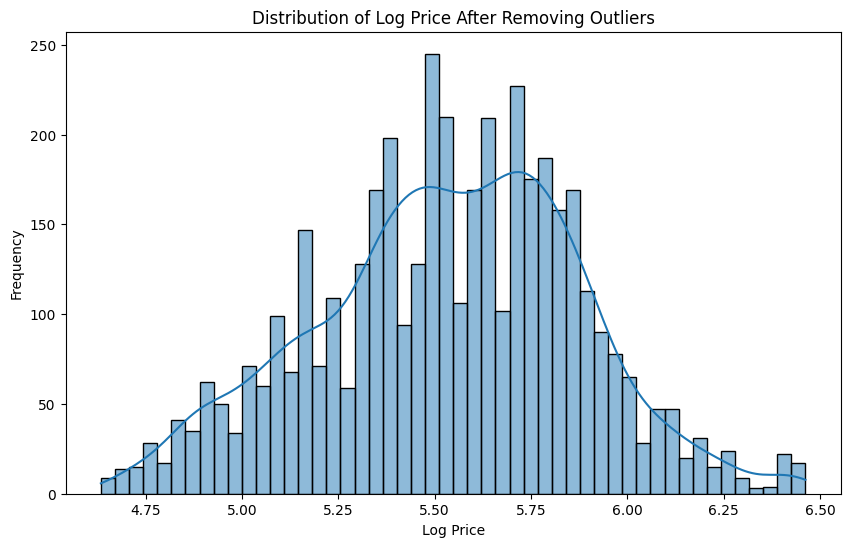

In [5]:
df['log_price'] = np.log10(df['selling_price'])

Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['log_price'] >= (Q1 - 1.5 * IQR)) & (df['log_price'] <= (Q3 + 1.5 * IQR))]

plt.figure(figsize=(10, 6))
sns.histplot(df['log_price'], kde=True, bins=50)
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.title('Distribution of Log Price After Removing Outliers')
plt.show()


## 🚗 4. Extracting Car Age & Encoding Categorical Data


In [6]:
current_year = 2024
df["car_age"] = current_year - df["year"]

le = LabelEncoder()
df['owner'] = le.fit_transform(df['owner'])
df['transmission'] = le.fit_transform(df['transmission'])
df['seller_type'] = le.fit_transform(df['seller_type'])
df['fuel'] = le.fit_transform(df['fuel'])

df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,log_price,car_age
0,Maruti 800 AC,2007,60000,70000,4,1,1,0,4.778151,17
1,Maruti Wagon R LXI Minor,2007,135000,50000,4,1,1,0,5.130334,17
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,1,0,5.778151,12
3,Datsun RediGO T Option,2017,250000,46000,4,1,1,0,5.397940,7
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,1,2,5.653213,10


## 📏 5. Data Normalization & Splitting


In [7]:
numeric_columns = ["km_driven"]

scaler = StandardScaler()
df_normalized = df.copy()
df_normalized[numeric_columns] = scaler.fit_transform(df[numeric_columns])

x = df_normalized.drop(columns=['selling_price', 'name', 'year', 'log_price'])
y = df_normalized['log_price']

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## 📈 6. Training a Linear Regression Model


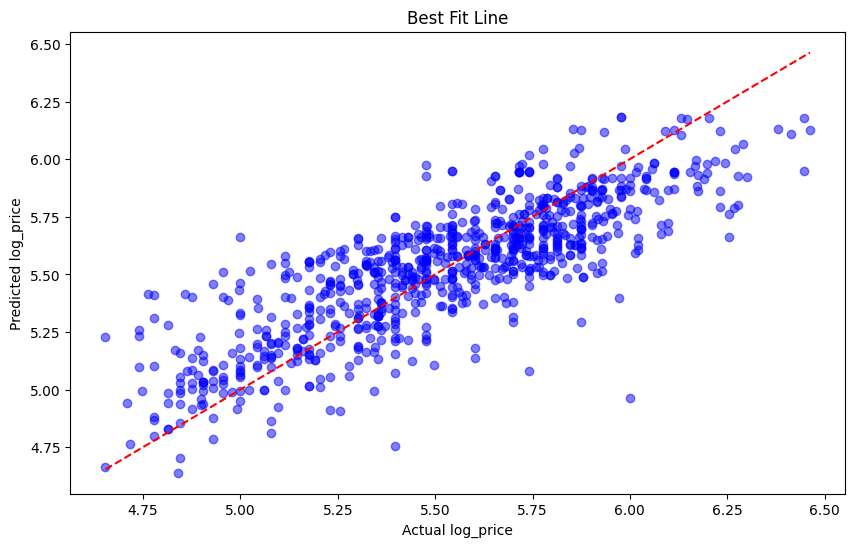

In [8]:
model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred, color='blue', alpha=0.5)
plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Best Fit Line')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.show()


## 📊 7. Model Evaluation


In [9]:
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {mse ** 0.5}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 0.04075257317161536
Mean Absolute Error (MAE): 0.15637485471823132
Root Mean Squared Error (RMSE): 0.20187266573663548
R-squared (R²): 0.6719611618874589


## 🏎️ 8. KNN Model Training & Evaluation


In [10]:
print("\nK-Nearest Neighbors:")

knn_reg = KNeighborsRegressor(n_neighbors=5)
model_knn=knn_reg.fit(X_train, Y_train)
y_pred_knn = knn_reg.predict(X_test)
mse_knn = mean_squared_error(Y_test, y_pred_knn)
r2_knn = r2_score(Y_test, y_pred_knn)
mae_knn = mean_absolute_error(Y_test, y_pred_knn)

print("accuracy for knn : ", knn_reg.score(X_test,Y_test))
print("score training data (K-Nearest Neighbors):", knn_reg.score(X_train, Y_train))
print("score testing data (K-Nearest Neighbors):", knn_reg.score(X_test, Y_test))
print("Mean Squared Error (KNN):", mse_knn)
print("R-squared (KNN):", r2_knn)
print("Mean Absolute Error (KNN):", mae_knn)


K-Nearest Neighbors:
accuracy for knn :  0.6503032662406091
score training data (K-Nearest Neighbors): 0.7542890311442022
score testing data (K-Nearest Neighbors): 0.6503032662406091
Mean Squared Error (KNN): 0.043443153903365964
R-squared (KNN): 0.6503032662406091
Mean Absolute Error (KNN): 0.15433491316734493


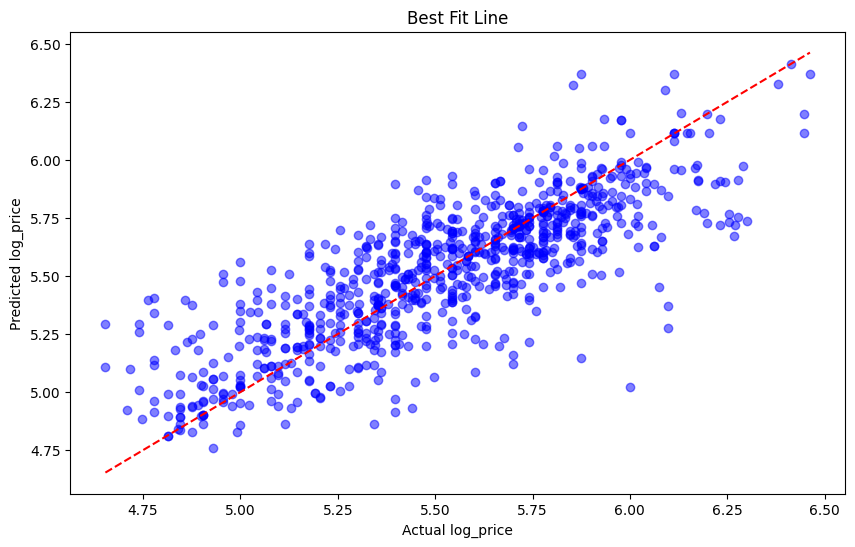

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, y_pred_knn, color='blue', alpha=0.5)  
plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Best Fit Line')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  
plt.show()